# Kinematics Analysis

Here the kinematics of the given globular clusters in the Milky Way will be analaysed. 

In [9]:
# Import libraries. Note: For me, cmasher keeps crashing the kernel so I have not used it thus far. However, I do not think it is necessary.

from math import log10, floor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colours


In [2]:
# Load Harris Part I which contains data relating to positions.
data1 = pd.read_csv("../data/raw/HarrisPartI.csv")
# Load Harris Part III data, which contains the data relating to kinematics.
data3 = pd.read_csv("../data/raw/HarrisPartIII.csv")

In [3]:
# Confirm data is loaded correctly for Harris I
data1.head()
data1.columns

Index(['ID', 'Name', 'RA', 'DEC', 'L', 'B', 'R_Sun', 'R_gc', 'X', 'Y', 'Z'], dtype='str')

In [4]:
# Same check as above for Harris III
data3.head()
data3.columns

Index(['ID', 'v_r', 'v_r_e', 'v_LSR', 'sig_v', 'sig_v_e', 'c', 'r_c', 'r_h',
       'mu_V', 'rho_0', 'lg_tc', 'lg_th'],
      dtype='str')

In [4]:
# Check for missing values in the datasets
data1.isna().sum()
data3.isna().sum()

ID          0
v_r        14
v_r_e      14
v_LSR      14
sig_v      95
sig_v_e    95
c           1
r_c         1
r_h         5
mu_V       14
rho_0      14
lg_tc      14
lg_th       2
dtype: int64

In [5]:
# Merge data by their ID columns
data = pd.merge(data1, data3, on="ID", how="inner")

In [6]:
# Check the merged data
data.head()
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 23 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ID       157 non-null    str    
 1   Name     51 non-null     str    
 2   RA       157 non-null    str    
 3   DEC      157 non-null    str    
 4   L        157 non-null    float64
 5   B        157 non-null    float64
 6   R_Sun    157 non-null    float64
 7   R_gc     157 non-null    float64
 8   X        157 non-null    float64
 9   Y        157 non-null    float64
 10  Z        157 non-null    float64
 11  v_r      143 non-null    float64
 12  v_r_e    143 non-null    float64
 13  v_LSR    143 non-null    float64
 14  sig_v    62 non-null     float64
 15  sig_v_e  62 non-null     float64
 16  c        156 non-null    float64
 17  r_c      156 non-null    float64
 18  r_h      152 non-null    float64
 19  mu_V     143 non-null    float64
 20  rho_0    143 non-null    float64
 21  lg_tc    143 non-null    fl

Original Data labelling guide for Harris I.
- ID: Cluster identification number
- Name: Other commonly used cluster name
- RA,DEC: Right ascension and declination (epoch J2000)
- L,B: Galactic longitude and latitude (degrees)
- R_Sun: Distance from Sun (kiloparsecs)
- R_gc: Distance from Galactic center (kpc), assuming R_0=8.0 kpc
- X,Y,Z: Galactic distance components X,Y,Z in kiloparsecs, in a
    Sun-centered coordinate system; X points toward Galactic center, 
    Y in direction of Galactic rotation, Z toward North Galactic Pole

Original Data labelling guide for Harris III.
- ID: Identifier of the globular cluster
- v_r: Radial velocity
- v_r_e: Uncertainty in the radial velocity
- v_LSR: Radial velocity corrected to the Local Standard of Rest (LSR)
- sig_v: Central velocity dispersion
- sig_v_e: Uncertainty in the central velocity dispersion.
- c: Concentration parameter (how dense the core is compared to its outer edge)
- r_c: Core radius
- r_h: Half-light radius
- mu_V: Central surface brightness in the V (visual) band
- rho_0: Central mass density
- lg_tc: Base-10 logarithm of the core relaxation time
- lg_th: Base-to logarithm of the half-mass relaxation time.

In [7]:
# Confirm the total number of clusters between all data sets align.
print("Harris I", len(data1), "Harris III", len(data3), "Merged", len(data))
print(data["ID"].nunique())

Harris I 157 Harris III 157 Merged 157
157


In [13]:
# Define variables from the Harris PI data.
L = data1['L']
B = data1['B']
X = data1['X']
Y = data1['Y']
Z = data1['Z']

# Define variables from the Harris PIII data.
v_r = data3['v_r']
v_r_e = data3['v_r_e']
sig_v = data3['sig_v']
sig_v_e = data3['sig_v_e']
c = data3['c']
r_h = data3['r_h']
rho_0 = data3['rho_0']
v_LSR = data3['v_LSR']

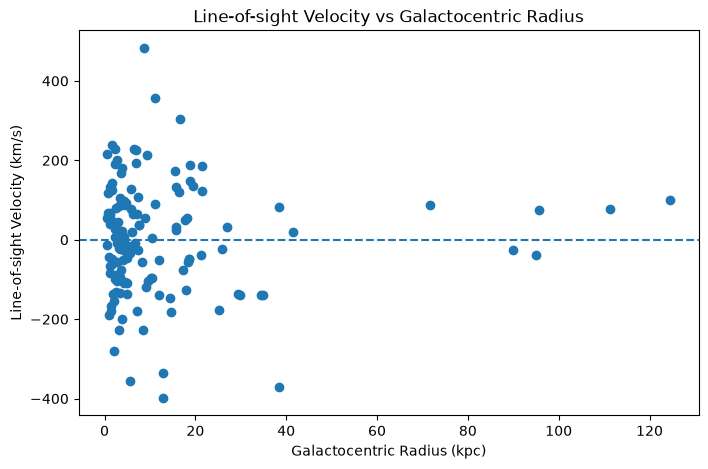

In [10]:
# Plot the line-of-sight velocity against the galactocentric radius. OH MY GOD IT WORKED.
plt.figure(figsize=(8,5))

plt.scatter(
    data["R_gc"],
    data["v_LSR"]
)   

plt.axhline(0, linestyle="--")

plt.xlabel("Galactocentric Radius (kpc)")
plt.ylabel("Line-of-sight Velocity (km/s)")
plt.title("Line-of-sight Velocity vs Galactocentric Radius")

plt.show()
